# 02 — Feature Engineering (Early Window)

Build **weeks 1–3** features (`date <= 21`) for early at-risk detection.

**Key findings from 01:**
- 32,593 enrollments; **52.8% at-risk** (Withdrawn + Fail)
- Strongest full-term signals: `active_days` (−0.63), `total_clicks` (−0.48), `mean_score` (−0.43)
- 20.8% missing `mean_score` (mostly withdrawn students with no submissions)
- `late_submission_count` is **lower** for at-risk students — withdrawn learners stop submitting, so lateness is a weak/noisy signal

This notebook restricts features to the **first 21 days** to avoid leakage from post-withdrawal behavior.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

EARLY_WINDOW_DAYS = 21  # weeks 1–3 (OULAD dates are days from course start)

print(f"Early window: day 0 – {EARLY_WINDOW_DAYS}")

Early window: day 0 – 21


## 1. Load raw tables & target

In [2]:
student_info = pd.read_csv(RAW / "studentInfo.csv")
student_assessment = pd.read_csv(RAW / "studentAssessment.csv")
assessments = pd.read_csv(RAW / "assessments.csv")
student_vle = pd.read_csv(RAW / "studentVle.csv")
vle = pd.read_csv(RAW / "vle.csv")

student_info["at_risk"] = student_info["final_result"].isin(["Withdrawn", "Fail"]).astype(int)

keys = ["code_module", "code_presentation", "id_student"]
print(f"Enrollments: {len(student_info):,}  |  At-risk rate: {student_info['at_risk'].mean():.1%}")

Enrollments: 32,593  |  At-risk rate: 52.8%


## 2. Early VLE engagement features

In [3]:
vle_early = student_vle[student_vle["date"] <= EARLY_WINDOW_DAYS].copy()
print(f"VLE rows in early window: {len(vle_early):,} / {len(student_vle):,}")

vle_early_agg = (
    vle_early.groupby(keys, as_index=False)
    .agg(
        early_clicks=("sum_click", "sum"),
        early_active_days=("date", "nunique"),
        early_first_activity=("date", "min"),
        early_last_activity=("date", "max"),
        early_unique_resources=("id_site", "nunique"),
    )
)

# Days since last login within the early window (staleness by end of week 3)
vle_early_agg["days_since_last_login"] = EARLY_WINDOW_DAYS - vle_early_agg["early_last_activity"]
vle_early_agg.loc[vle_early_agg["early_clicks"] == 0, "days_since_last_login"] = EARLY_WINDOW_DAYS

vle_early_agg.head()

VLE rows in early window: 2,393,004 / 10,655,280


,code_module,code_presentation,id_student,early_clicks,early_active_days,early_first_activity,early_last_activity,early_unique_resources,days_since_last_login
0,AAA,2013J,11391,401,8,-5,18,24,3
1,AAA,2013J,28400,493,15,-10,16,30,5
2,AAA,2013J,30268,281,12,-10,12,22,9
3,AAA,2013J,31604,453,17,-10,20,30,1
4,AAA,2013J,32885,518,21,-10,21,33,0


In [4]:
# Resource-type diversity (forum, content, url, etc.)
vle_labeled = vle_early.merge(
    vle[["id_site", "activity_type"]],
    on="id_site",
    how="left",
)

vle_diversity = (
    vle_labeled.groupby(keys, as_index=False)
    .agg(vle_diversity=("activity_type", "nunique"))
)

vle_early_agg = vle_early_agg.merge(vle_diversity, on=keys, how="left")
vle_early_agg["vle_diversity"] = vle_early_agg["vle_diversity"].fillna(0)
vle_early_agg.head()

,code_module,code_presentation,id_student,early_clicks,early_active_days,early_first_activity,early_last_activity,early_unique_resources,days_since_last_login,vle_diversity
0,AAA,2013J,11391,401,8,-5,18,24,3,6
1,AAA,2013J,28400,493,15,-10,16,30,5,6
2,AAA,2013J,30268,281,12,-10,12,22,9,6
3,AAA,2013J,31604,453,17,-10,20,30,1,7
4,AAA,2013J,32885,518,21,-10,21,33,0,7


## 3. Early assessment features

In [5]:
sa = student_assessment.merge(assessments, on="id_assessment", how="inner")

# Only assessments due within the first 3 weeks
sa_early = sa[sa["date"] <= EARLY_WINDOW_DAYS].copy()
sa_early["late"] = np.where(
    sa_early["date"].notna(),
    sa_early["date_submitted"] > sa_early["date"],
    np.nan,
)

assess_early_agg = (
    sa_early.groupby(keys, as_index=False)
    .agg(
        early_mean_score=("score", "mean"),
        early_n_assessments=("score", "count"),
        early_late_count=("late", "sum"),
    )
)

# Submissions that happened early (even if due later) — activity signal
sa_submitted_early = sa[sa["date_submitted"] <= EARLY_WINDOW_DAYS]
submit_early_agg = (
    sa_submitted_early.groupby(keys, as_index=False)
    .agg(
        early_submissions=("score", "count"),
        early_submit_mean_score=("score", "mean"),
    )
)

assess_early_agg = assess_early_agg.merge(submit_early_agg, on=keys, how="left")
assess_early_agg.head()

,code_module,code_presentation,id_student,early_mean_score,early_n_assessments,early_late_count,early_submissions,early_submit_mean_score
0,AAA,2013J,11391,78.0,1,0.0,1.0,78.0
1,AAA,2013J,28400,70.0,1,1.0,NaN,NaN
2,AAA,2013J,31604,72.0,1,0.0,1.0,72.0
3,AAA,2013J,32885,69.0,1,1.0,NaN,NaN
4,AAA,2013J,38053,79.0,1,0.0,1.0,79.0


## 4. Merge demographics + early features

In [6]:
demo_cols = [
    "gender", "region", "highest_education", "imd_band",
    "age_band", "num_of_prev_attempts", "studied_credits", "disability",
]

df = (
    student_info[keys + ["final_result", "at_risk"] + demo_cols]
    .merge(vle_early_agg, on=keys, how="left")
    .merge(assess_early_agg, on=keys, how="left")
)

# Fill count features with 0 where student had no early activity
zero_fill = [
    "early_clicks", "early_active_days", "early_unique_resources",
    "vle_diversity", "early_n_assessments", "early_late_count",
    "early_submissions", "days_since_last_login",
]
df[zero_fill] = df[zero_fill].fillna(0)

# Students with no early VLE activity
df.loc[df["early_clicks"] == 0, ["early_first_activity", "early_last_activity"]] = np.nan

print(f"Feature table shape: {df.shape}")
print(f"At-risk rate: {df['at_risk'].mean():.1%}")
df.head()

Feature table shape: (32593, 25)
At-risk rate: 52.8%


,code_module,code_presentation,id_student,final_result,at_risk,gender,region,highest_education,imd_band,age_band,...,early_first_activity,early_last_activity,early_unique_resources,days_since_last_login,vle_diversity,early_mean_score,early_n_assessments,early_late_count,early_submissions,early_submit_mean_score
0,AAA,2013J,11391,Pass,0,M,East Anglian Region,HE Qualification,90-100%,55<=,...,-5.0,18.0,24.0,3.0,6.0,78.0,1.0,0.0,1.0,78.0
1,AAA,2013J,28400,Pass,0,F,Scotland,HE Qualification,20-30%,35-55,...,-10.0,16.0,30.0,5.0,6.0,70.0,1.0,1.0,0.0,NaN
2,AAA,2013J,30268,Withdrawn,1,F,North Western Region,A Level or Equivalent,30-40%,35-55,...,-10.0,12.0,22.0,9.0,6.0,NaN,0.0,0.0,0.0,NaN
3,AAA,2013J,31604,Pass,0,F,South East Region,A Level or Equivalent,50-60%,35-55,...,-10.0,20.0,30.0,1.0,7.0,72.0,1.0,0.0,1.0,72.0
4,AAA,2013J,32885,Pass,0,F,West Midlands Region,Lower Than A Level,50-60%,0-35,...,-10.0,21.0,33.0,0.0,7.0,69.0,1.0,1.0,0.0,NaN


## 5. Early-feature EDA

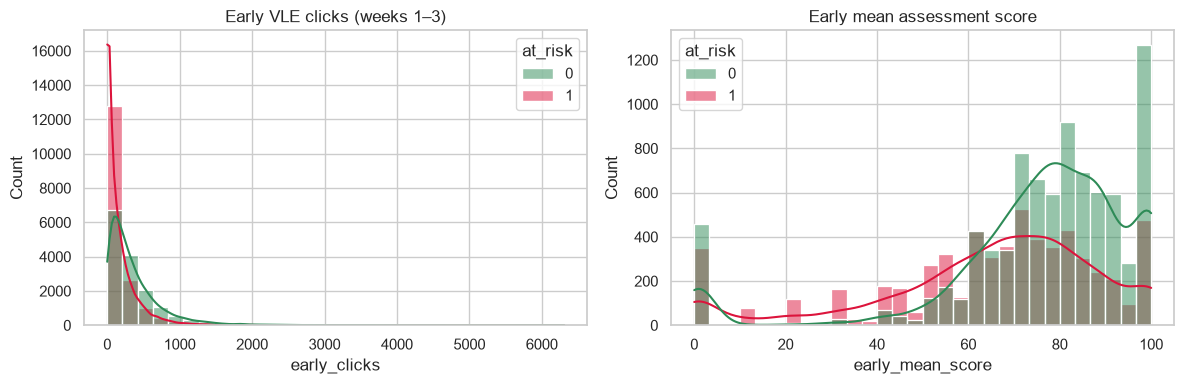

In [7]:
early_numeric = [
    "early_clicks", "early_active_days", "vle_diversity",
    "early_mean_score", "early_submissions", "days_since_last_login", "at_risk",
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(
    axes,
    ["early_clicks", "early_mean_score"],
    ["Early VLE clicks (weeks 1–3)", "Early mean assessment score"],
):
    plot_df = df.dropna(subset=[col]) if col == "early_mean_score" else df
    sns.histplot(
        data=plot_df, x=col, hue="at_risk", bins=30, kde=True, ax=ax,
        palette={0: "seagreen", 1: "crimson"}, common_norm=False,
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

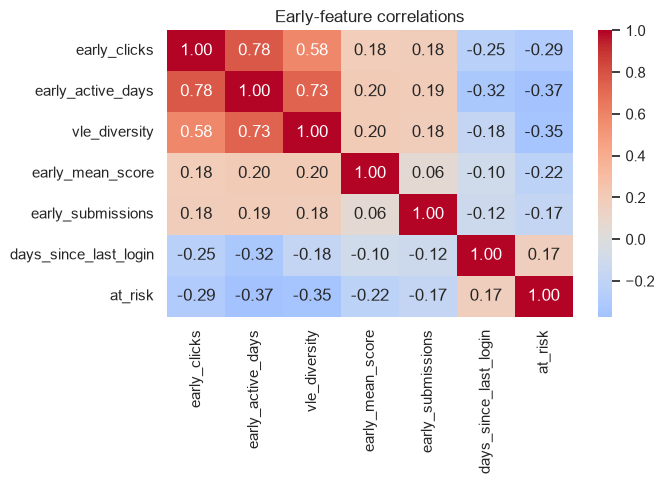

Correlation with at_risk:
early_active_days       -0.372
vle_diversity           -0.354
early_clicks            -0.291
early_mean_score        -0.222
early_submissions       -0.173
days_since_last_login    0.175
Name: at_risk, dtype: float64


In [8]:
corr = df[early_numeric].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0, ax=ax)
ax.set_title("Early-feature correlations")
plt.tight_layout()
plt.show()

print("Correlation with at_risk:")
print(corr["at_risk"].drop("at_risk").sort_values().round(3))

In [9]:
summary_cols = [
    "early_clicks", "early_active_days", "vle_diversity",
    "early_mean_score", "early_submissions", "days_since_last_login",
]
df.groupby("at_risk")[summary_cols].agg(["mean", "median"]).round(2)

early_clicks        early_active_days        vle_diversity         \
                mean median              mean median          mean median   
at_risk                                                                     
0             367.69  249.0             14.08   13.0          7.12    7.0   
1             163.24   76.0              7.43    5.0          4.94    6.0   

        early_mean_score        early_submissions         \
                    mean median              mean median   
at_risk                                                    
0                  75.54   80.0              0.60    1.0   
1                  64.64   70.0              0.36    0.0   

        days_since_last_login         
                         mean median  
at_risk                               
0                        2.39    1.0  
1                        4.57    2.0

## 6. Save modeling-ready dataset

Feeds `03_model_training.ipynb`. Score columns may be NaN for students with no early submissions — tree models handle this; impute or drop for logistic regression.

In [10]:
out_path = PROCESSED / "student_features_early.csv"
df.to_csv(out_path, index=False)

feature_cols = [c for c in df.columns if c not in keys + ["final_result", "at_risk"]]
print(f"Saved {df.shape[0]:,} rows → {out_path}")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Saved 32,593 rows → d:\ed_project\data\processed\student_features_early.csv
Feature columns (20): ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'early_clicks', 'early_active_days', 'early_first_activity', 'early_last_activity', 'early_unique_resources', 'days_since_last_login', 'vle_diversity', 'early_mean_score', 'early_n_assessments', 'early_late_count', 'early_submissions', 'early_submit_mean_score']
